# Actividad 04 - Clustering con dataset Moons
Modelos: K-means, DBSCAN y SpectralClustering

Métricas externas: Adjusted Rand Index (ARI), V-measure

Métricas internas: Silhouette Score, Davies-Bouldin Index, Elbow Method

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import adjusted_rand_score, v_measure_score, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

## 1. Generar el dataset Moons

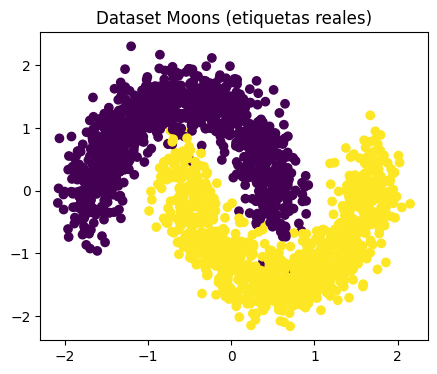

In [ ]:
# Generamos el dataset sintetico moons con ruido
datosX, etiquetasReales = make_moons(n_samples=2000, noise=0.15, random_state=42)

# Escalamos los datos para que los algoritmos basados en distancia funcionen mejor
escalador = StandardScaler()
datosXEscalados = escalador.fit_transform(datosX)

# Visualizamos el dataset original
plt.figure(figsize=(5,4))
plt.scatter(datosXEscalados[:,0], datosXEscalados[:,1], c=etiquetasReales, cmap='viridis')
plt.title('Dataset Moons (etiquetas reales)')
plt.show()

## 2. Elbow Method (para K-means)

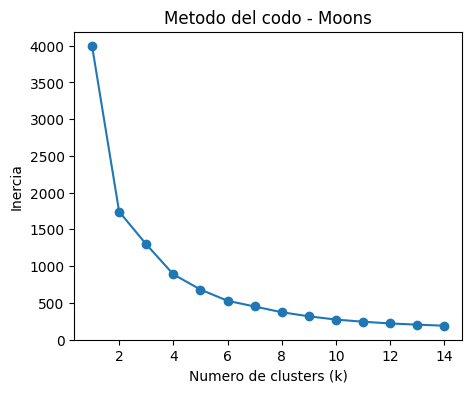

In [ ]:
# Calculamos la inercia para distintos valores de k
valoresInercia = []
rangoK = range(1, 15)

for k in rangoK:
    modeloKmeansTemp = KMeans(n_clusters=k, random_state=42, n_init=20)
    modeloKmeansTemp.fit(datosXEscalados)
    valoresInercia.append(modeloKmeansTemp.inertia_)

plt.figure(figsize=(5,4))
plt.plot(rangoK, valoresInercia, marker='o')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inercia')
plt.title('Metodo del codo - Moons')
plt.show()

## 3. Entrenamiento de los modelos

In [ ]:
# K-means con k=2 segun el elbow y el numero real de grupos
modeloKmeans = KMeans(n_clusters=2, random_state=42, n_init=20, max_iter=500)
etiquetasKmeans = modeloKmeans.fit_predict(datosXEscalados)

# DBSCAN, hiperparametros criticos eps y min_samples
modeloDbscan = DBSCAN(eps=0.15, min_samples=15)
etiquetasDbscan = modeloDbscan.fit_predict(datosXEscalados)

# SpectralClustering, util para formas no lineales
modeloSpectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=50,
                                     random_state=42)
etiquetasSpectral = modeloSpectral.fit_predict(datosXEscalados)

## 4. Visualizacion de resultados

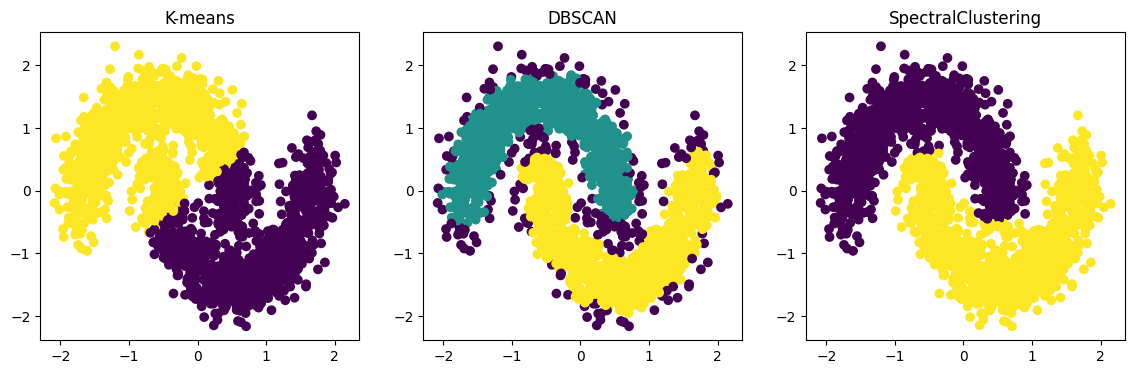

In [ ]:
figura, ejes = plt.subplots(1, 3, figsize=(14,4))

ejes[0].scatter(datosXEscalados[:,0], datosXEscalados[:,1], c=etiquetasKmeans, cmap='viridis')
ejes[0].set_title('K-means')

ejes[1].scatter(datosXEscalados[:,0], datosXEscalados[:,1], c=etiquetasDbscan, cmap='viridis')
ejes[1].set_title('DBSCAN')

ejes[2].scatter(datosXEscalados[:,0], datosXEscalados[:,1], c=etiquetasSpectral, cmap='viridis')
ejes[2].set_title('SpectralClustering')

plt.show()

## 5. Metricas de validacion externa e interna

In [ ]:
# Funcion auxiliar para calcular metricas, manejando el caso de ruido en DBSCAN
def calcularMetricas(nombreModelo, etiquetasPredichas):
    ari = adjusted_rand_score(etiquetasReales, etiquetasPredichas)
    vMeasure = v_measure_score(etiquetasReales, etiquetasPredichas)

    # Silhouette y Davies-Bouldin requieren al menos 2 clusters validos
    numeroClusters = len(set(etiquetasPredichas)) - (1 if -1 in etiquetasPredichas else 0)

    if numeroClusters >= 2:
        silhouette = silhouette_score(datosXEscalados, etiquetasPredichas)
        davisBouldin = davies_bouldin_score(datosXEscalados, etiquetasPredichas)
    else:
        silhouette = np.nan
        davisBouldin = np.nan

    print(f'--- {nombreModelo} ---')
    print(f'ARI: {ari:.3f}')
    print(f'V-measure: {vMeasure:.3f}')
    print(f'Silhouette: {silhouette:.3f}')
    print(f'Davies-Bouldin: {davisBouldin:.3f}')
    print()

calcularMetricas('K-means', etiquetasKmeans)
calcularMetricas('DBSCAN', etiquetasDbscan)
calcularMetricas('SpectralClustering', etiquetasSpectral)

--- K-means ---
ARI: 0.491
V-measure: 0.391
Silhouette: 0.482
Davies-Bouldin: 0.824

--- DBSCAN ---
ARI: 0.781
V-measure: 0.725
Silhouette: 0.234
Davies-Bouldin: 2.568

--- SpectralClustering ---
ARI: 0.937
V-measure: 0.883
Silhouette: 0.390
Davies-Bouldin: 0.997

